In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [ ]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.optimize import linear_sum_assignment

from imports import *
from config import dir_config, main_config
from src.utils import pmf_utils
from src.shared_glm_hmm.grouping import session_metadata

In [ ]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(metadata).set_index("session_id")

# trial-level behaviour (for per-trial color when a config lacks the color regressor)
behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
behavior_df["outcome"] = behavior_df["outcome"].fillna(-1)

SELECTED_MODEL = main_config.GLM_HMM.final_model


## Select model for the within-subject analysis

The panels above compare all runs. Pick **one** model here; sections 1–6 below run on it.

In [ ]:
bundle = pickle.load(open(shared_dir / SELECTED_MODEL / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
feats = bundle["config"]["model_features"]
K = bundle["best_k"]
data = bundle["data"]


STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3", "#a65628", "#999999"]
GROUP_LABELS = {
    ("HC", "none"): "HC",
    ("tremor", "off"): "Tremor OFF",
    ("tremor", "on"): "Tremor ON",
    ("bradykinetic", "off"): "Brady OFF",
    ("bradykinetic", "on"): "Brady ON",
    ("intermediate", "off"): "Interm OFF",
    ("intermediate", "on"): "Interm ON",
}

In [ ]:
def get_state_colors(Kn):
    return [STATE_COLORS[k % len(STATE_COLORS)] for k in range(Kn)]


def state_label(k):
    return f"State {k + 1}"


def _align(w, ref):
    cost = np.array([[np.sum((w[i] - ref[j]) ** 2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col)
    inv[col] = np.arange(len(col))
    return inv


def get_session_color(sid, n_back):
    """Per-trial color for one session, trimmed to match the bundle (process_sessions logic)."""
    td = behavior_df[behavior_df["session_id"] == sid].reset_index(drop=True)
    valid_idx = np.where(td["outcome"].values != -1)[0]
    first_trial = valid_idx[n_back - 1] + 1
    return td["color"].values[first_trial:]


def build_group_data(bundle, sess_md):
    """{group_tuple: {session_weights, session_occupancy, session_predicted_dfs}} on shared basis."""
    ref_w = -bundle["model"]["pooled"].observations.params[:, 0, :]  # (K, M) this run's shared basis
    n_back = bundle["config"].get("n_trials_back", 1)
    groups = {}
    for sid, m in bundle["model"]["models"].items():
        if sid not in sess_md.index:
            continue
        g = (sess_md.loc[sid, "subtype"], sess_md.loc[sid, "medication"])
        df = bundle["data"][sid]
        X = df[feats].values.astype(float)
        y = df["choices"].values.astype(int).reshape(-1, 1)
        msk = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=y, input=X, mask=msk)[0]  # (T, K)
        w = -m.observations.params[:, 0, :]
        perm = _align(w, ref_w)
        valid = msk[:, 0]
        # expected choice prob (permutation-invariant)
        wsum = np.einsum("tm,km->tk", X, w)
        sig = 1 / (1 + np.exp(-wsum))
        ecp = (sig * post).sum(1)
        color_raw = df["color"].values if "color" in df.columns else get_session_color(sid, n_back)
        pdf = pd.DataFrame(
            {
                "stimulus": df["stimulus"].values[valid],
                "choices": y[valid, 0],
                "color": (color_raw[valid] > 0).astype(int),  # equal=0, unequal=1
                "expected_choice_prob": np.clip(ecp[valid], 1e-6, 1 - 1e-6),
            }
        )
        gd = groups.setdefault(g, {"session_weights": {}, "session_occupancy": {}, "session_predicted_dfs": {}})
        gd["session_weights"][sid] = w[perm]
        gd["session_occupancy"][sid] = post[:, perm][valid].mean(0)
        gd["session_predicted_dfs"][sid] = pdf
    return groups


def compute_group_psychometrics(predicted_dfs):
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}
    for cval, label, color in conditions:
        actual, model = [], []
        x_bins = x_hat = None
        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == cval]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch = sub["choices"].values.astype(int)
            ep = sub["expected_choice_prob"].values
            try:
                xd, yd, _, xh, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual.append(yd)
                if x_bins is None:
                    x_bins, x_hat = xd, xh
                # _, ym, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": npr.binomial(1, ep)})
                ym = np.array([ep[stim == c].mean() for c in x_bins])
                model.append(ym)
            except Exception:
                continue
        if not actual:
            continue
        ya, ym = np.array(actual), np.array(model)
        S = len(actual)

        def safe_fit(y):
            try:
                return pmf_utils.fit_psychometric_function(x_bins, y, trial_counts=None, model_type="logit_4").predict(x_hat)
            except Exception:
                return None

        result[cval] = dict(
            label=label,
            color=color,
            x_bins=x_bins,
            x_hat=x_hat,
            actual=actual,
            model=model,
            mean_actual=ya.mean(0),
            sem_actual=ya.std(0) / np.sqrt(S),
            mean_model=ym.mean(0),
            sem_model=ym.std(0) / np.sqrt(S),
            fit_actual=safe_fit(ya.mean(0)),
            fit_model=safe_fit(ym.mean(0)),
        )
    return result


def plot_color_psych(ax, gp, mode, title=""):
    for cval in sorted(gp):
        c = gp[cval]
        col = c["color"]
        for ys in c[mode]:
            ax.plot(c["x_bins"], ys, "o-", color=col, alpha=0.08, lw=0.8, ms=3)
        ax.errorbar(c["x_bins"], c[f"mean_{mode}"], yerr=c[f"sem_{mode}"], color=col, marker="o", ms=9, mec="k", ls="", label=c["label"], elinewidth=2, capsize=7)
        if c[f"fit_{mode}"] is not None:
            ax.plot(c["x_hat"], c[f"fit_{mode}"], color=col, ls="-", lw=2.5)
    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105, 105), ylim=(-0.05, 1.05), xticks=[-100, -35, -13, 0, 13, 35, 100], title=title)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)


def plot_group_row(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)
    ax_beh, ax_mdl, ax_psych, ax_w, ax_occ = axrow
    gp = compute_group_psychometrics(gd["session_predicted_dfs"])
    plot_color_psych(ax_beh, gp, "actual", f"{label} — Behavior")
    plot_color_psych(ax_mdl, gp, "model", f"{label} — GLM-HMM")

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None

    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    xr = np.linspace(-1, 1, 200)

    for k in range(K):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax_psych.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls, label=state_label(k))

    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=f"{label} — states")
    ax_psych.legend(fontsize=7)

    xf = np.arange(len(feats))
    for k in range(K):
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.4, capsize=3, label=state_label(k))
    ax_w.axhline(0, color="k", ls="--", lw=0.8)
    ax_w.set_xticks(xf)
    ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
    ax_w.set(ylabel="GLM weight", title="Weights (mean ± SEM)")
    ax_w.legend(fontsize=7)

    xk = np.arange(K)
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k + 1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")

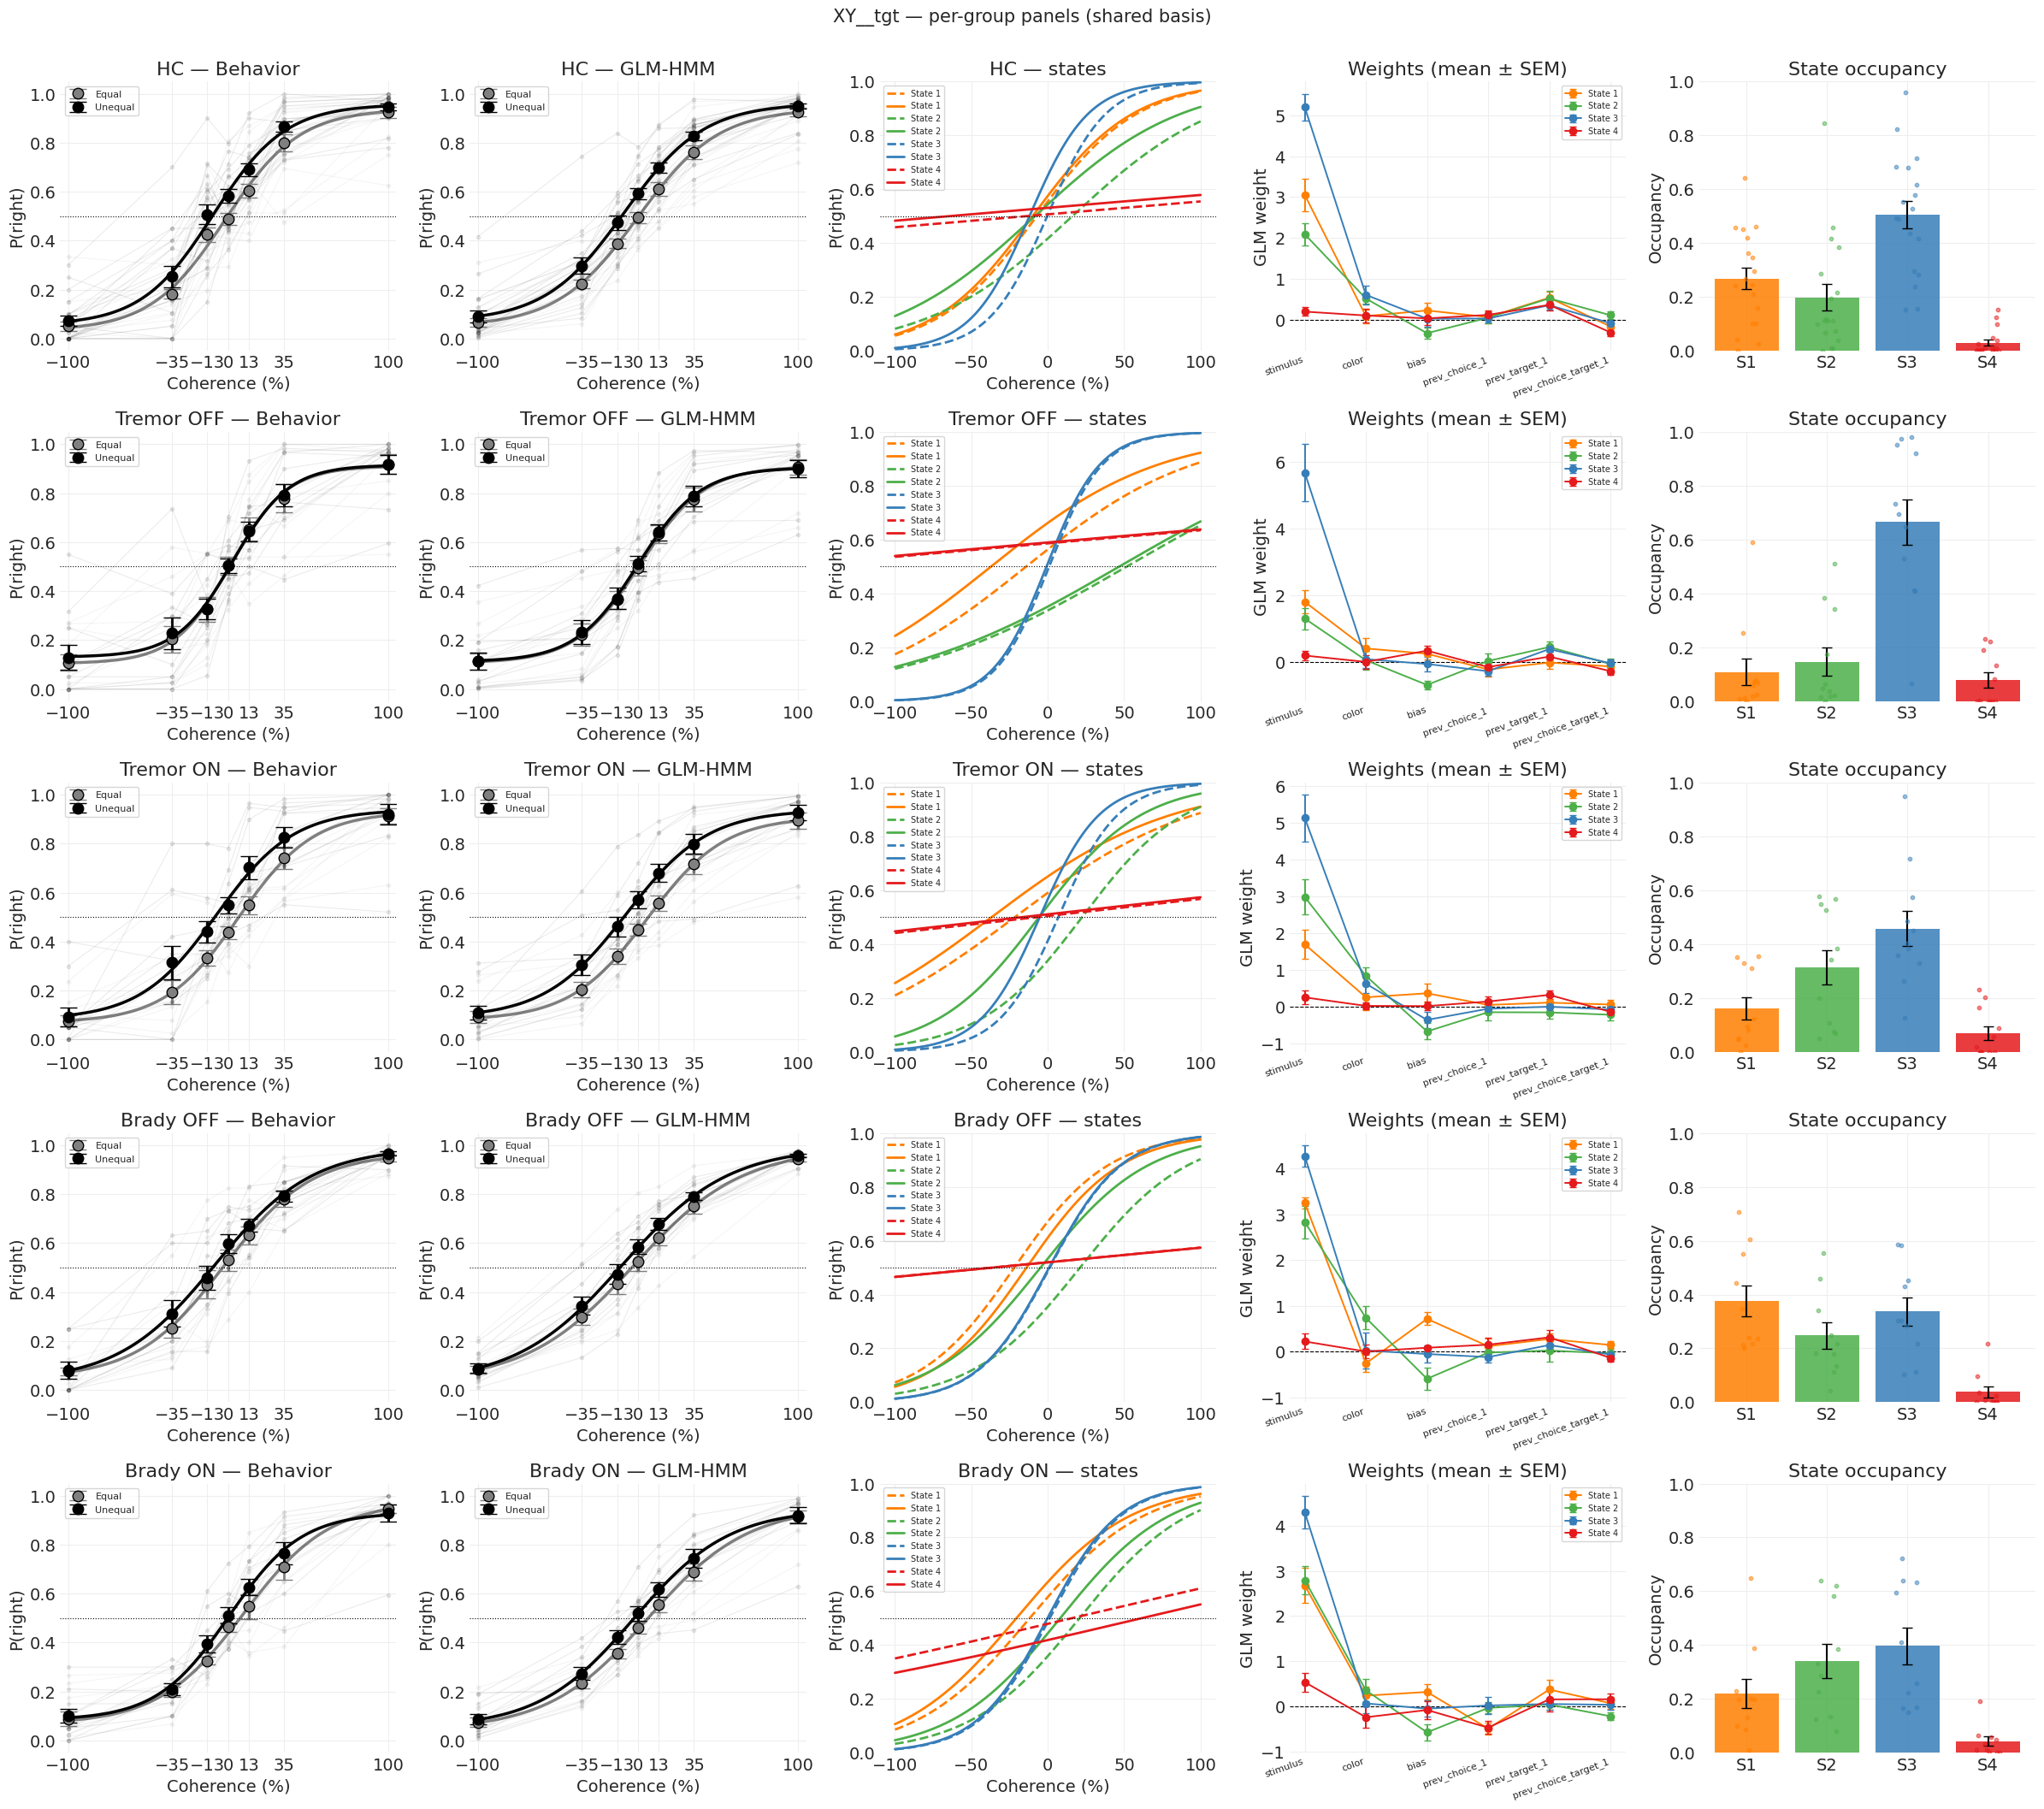

In [ ]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]

nG = len(GROUP_ORDER)
fig, axes = plt.subplots(nG, 5, figsize=(24, 4.2 * nG), squeeze=False)
for row, g in enumerate(GROUP_ORDER):
    plot_group_row(axes[row], g, group_data[g])
fig.suptitle(f"{SELECTED_MODEL} \u2014 per-group panels (shared basis)", fontsize=15, y=1.005)
plt.tight_layout()
plt.show()

# 0.1 Individual State Weight plots

In [ ]:
def plot_group_state_psych_weights(axrow, group, gd, title=None):

    GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)

    ax_psych = axrow[0, np.arange(0, 2 * K, 2)]
    ax_weights = axrow[0, np.arange(1, 2 * K, 2)]
    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None
    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    xf = np.arange(len(feats))
    for ax_w, k in zip(ax_weights, range(K)):
        ax_w.plot(Wg[:, k, :].T, color=colors[k], alpha=0.3, lw=0.8)
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color="k", marker="o", lw=2, capsize=3, label=state_label(k))
        ax_w.axhline(0, color="k", ls="--", lw=0.8)
        ax_w.set_xticks(xf)
        ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
        ax_w.set_ylim(-2.5, 8)
        ax_w.legend(fontsize=7)

    xr = np.linspace(-1, 1, 200)
    for ax, k in zip(ax_psych, range(K)):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls)

        ax.axhline(0.5, color="k", ls=":", lw=0.8)
        ax.set(xlabel="Coherence (%)", ylabel="P(positive)", ylim=(0, 1))  # , title=f"{label} — states")
        ax.legend(fontsize=7)

    # Add occupancy plot
    xk = np.arange(K)
    ax_occ = axrow[0, -1]
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k + 1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")

    if title:
        fig.suptitle(title, fontsize=25, y=1.05)

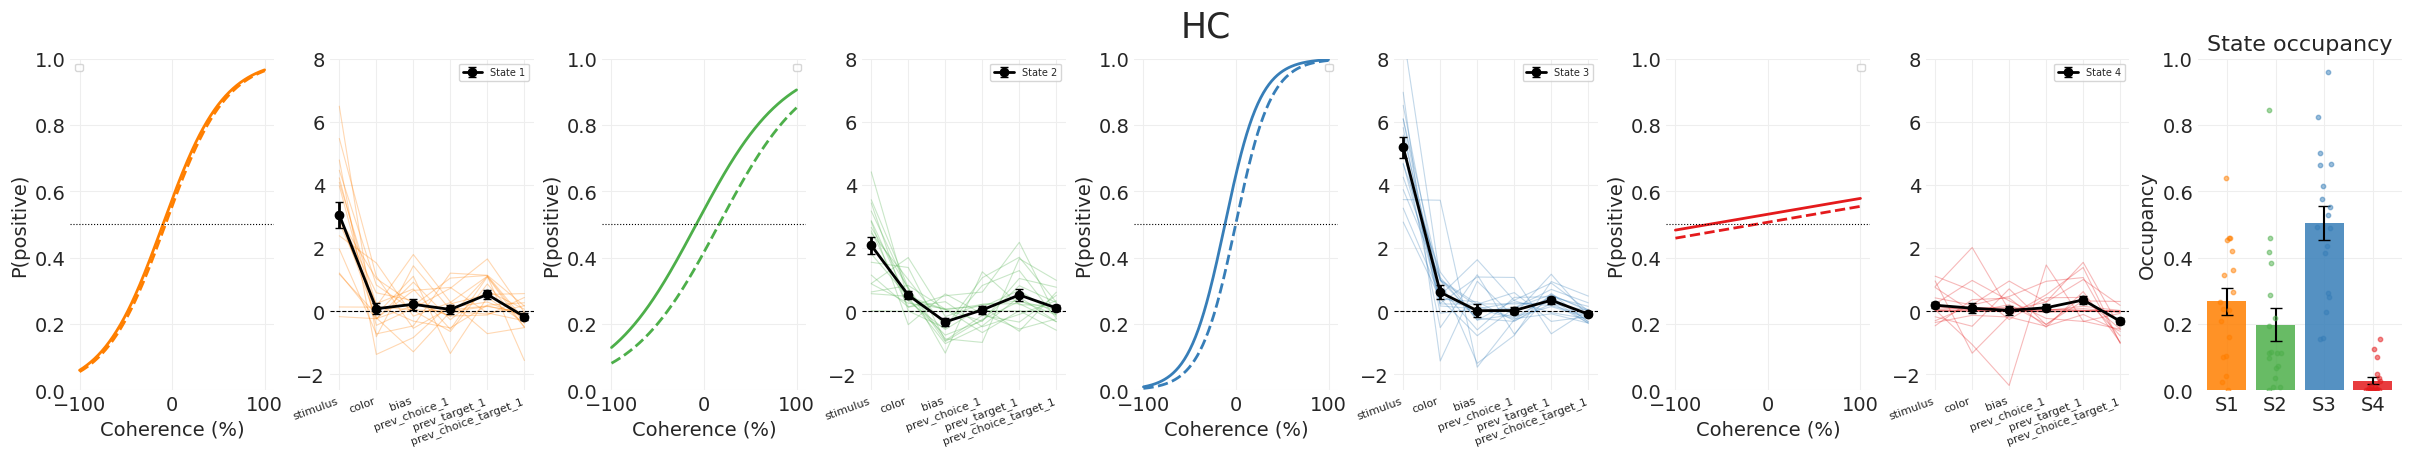

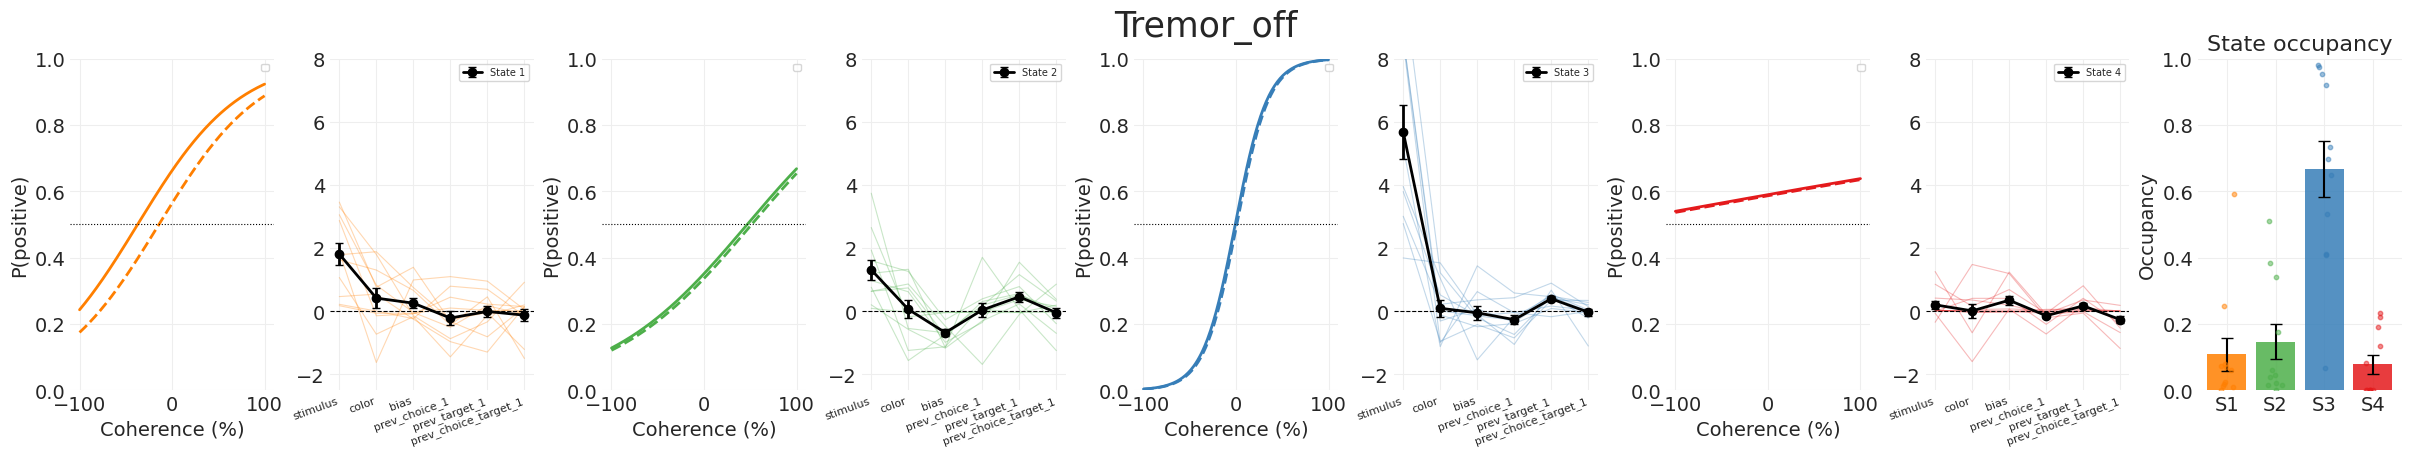

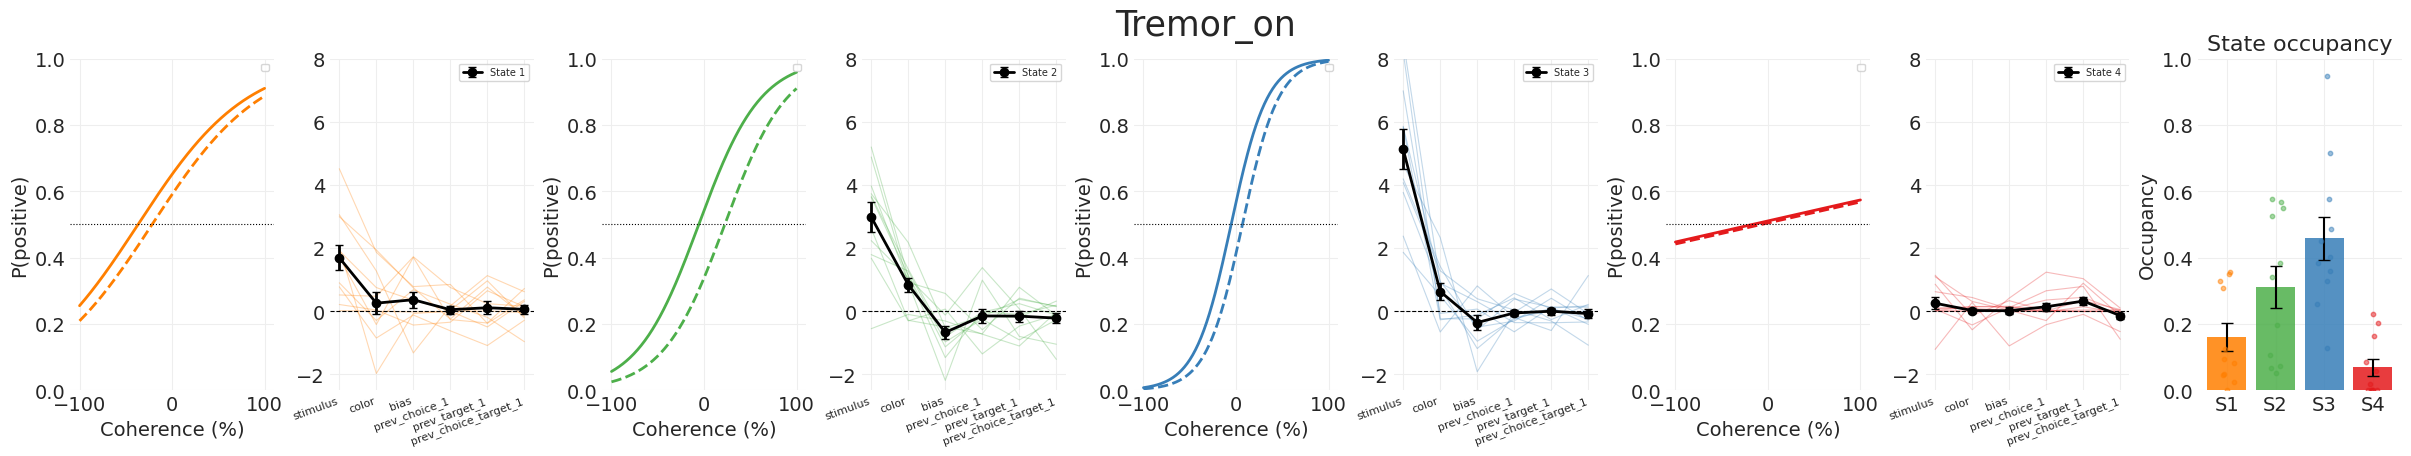

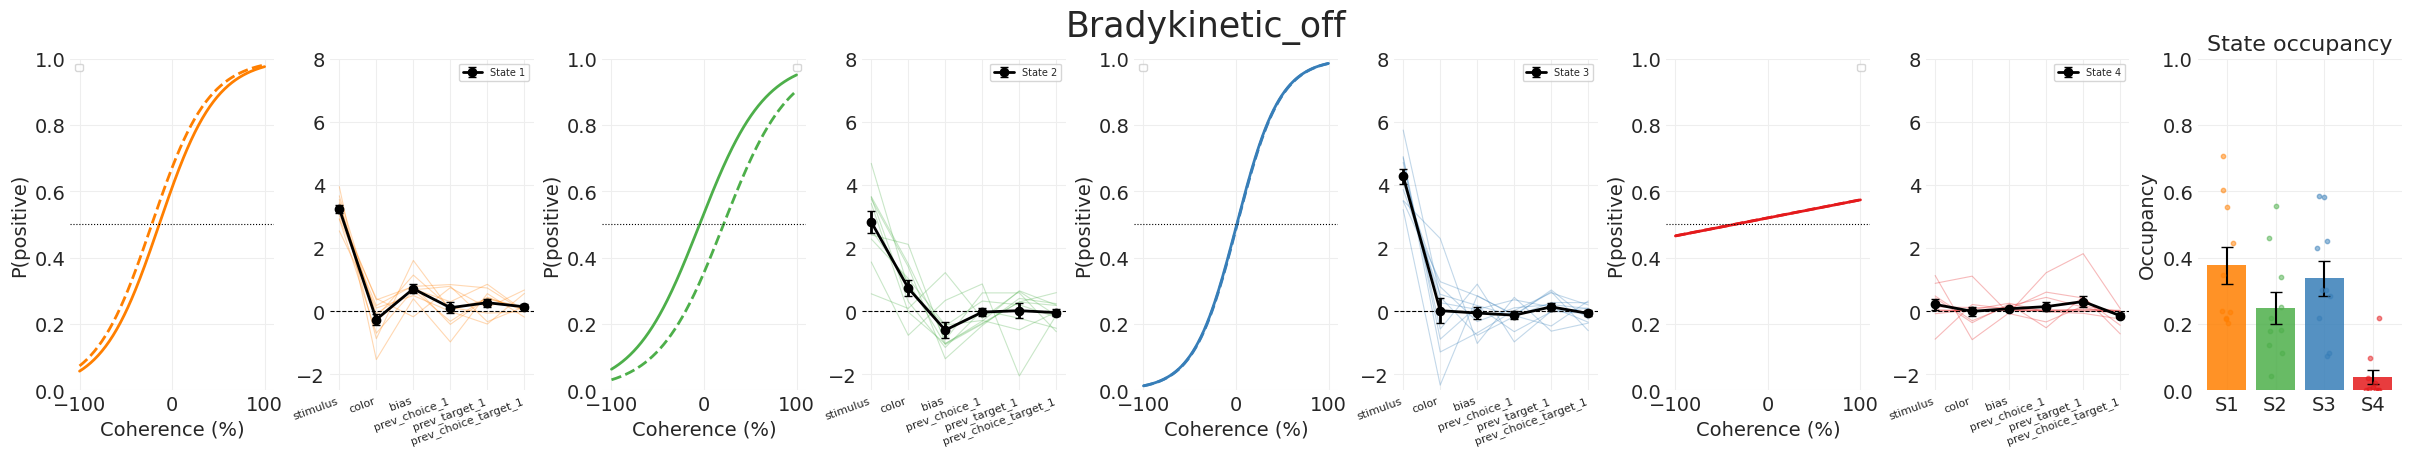

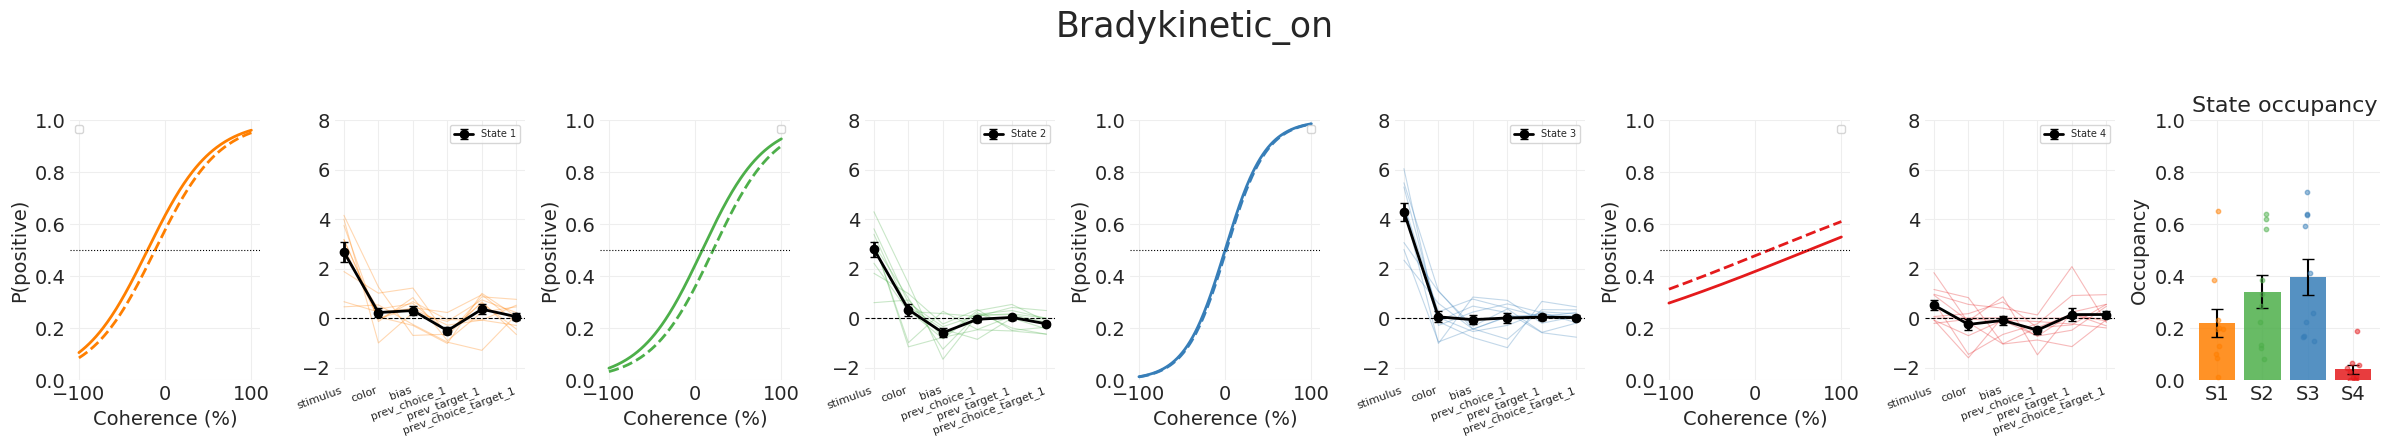

In [ ]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]
nG = len(GROUP_ORDER)

for row, g in enumerate(GROUP_ORDER):
    fig, axes = plt.subplots(1, 2 * K + 1, figsize=(24, 4.2), squeeze=False)
    title = f"{g[0].capitalize()}_{g[1]}" if g[0] != "HC" else f"{g[0]}"
    plot_group_state_psych_weights(axes, g, group_data[g], title=title)
plt.tight_layout()
plt.show()

# Significant Color-Bias States 

In [ ]:
from scipy.stats import bootstrap

_STATE_NAMES = {"S0": "Positive biased", "S1": "Negative biased", "S2": "Unbiased", "S3": "Lapse"}


def _sig(x):
    return 1.0 / (1.0 + np.exp(-x))


def get_sig_color_states(subtype, state, medication=None, B=10000, seed=0):
    """Does `state` show a significant color (prior) effect for `subtype`?

    Per session the prob-units shift at 0% coherence is  delta = sigmoid(bias+color) - sigmoid(bias)
    (stimulus term is 0 at zero coherence). Test delta vs 0 across the subtype's sessions with a
    one-sample Wilcoxon + BCa bootstrap 95% CI; significant = CI excludes 0. medication=None pools
    every session of the subtype (caveat: PD subjects then contribute OFF+ON -> not independent;
    pass medication="off" for an independent baseline test). Returns one summary row (dict).
    """
    bi, ci = feats.index("bias"), feats.index("color")
    keys = [g for g in group_data if g[0] == subtype and (medication is None or g[1] == medication)]
    W = [w for g in keys for w in group_data[g]["session_weights"].values()]  # list of (K, M)
    O = [o for g in keys for o in group_data[g]["session_occupancy"].values()]  # list of (K,)
    base = dict(subtype=subtype, state=f"S{state}", state_name=_STATE_NAMES.get(f"S{state}", f"S{state}"), medication=medication or "all", n=len(W))
    if len(W) < 3:
        return {**base, "color_w": np.nan, "delta": np.nan, "ci_lo": np.nan, "ci_hi": np.nan, "p": np.nan, "sig": False, "occupancy": np.nan}
    W, O = np.stack(W), np.stack(O)
    b, c = W[:, state, bi], W[:, state, ci]
    delta = _sig(b + c) - _sig(b)
    _, p = wilcoxon(delta)
    try:
        res = bootstrap((delta,), np.mean, method="BCa", n_resamples=B, random_state=seed)
    except Exception:
        res = bootstrap((delta,), np.mean, method="percentile", n_resamples=B, random_state=seed)
    lo, hi = res.confidence_interval
    return {**base, "color_w": float(c.mean()), "delta": float(delta.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "p": float(p), "sig": bool(lo > 0 or hi < 0), "occupancy": float(O[:, state].mean())}


def get_sig_color_effect_states_and_occupancy(subtype, medication=None):
    """Per-state color-effect significance + occupancy for a subtype, with a one-line summary."""
    rows = [get_sig_color_states(subtype, state, medication=medication) for state in range(K)]
    tbl = pd.DataFrame(rows).set_index(["subtype", "medication", "state"])
    sig = [(r["state_name"], r["occupancy"]) for r in rows if r["sig"]]
    occ_sig = float(np.sum([o for _, o in sig]))
    names = ", ".join(f"{nm} (occ={o:.2f})" for nm, o in sig) if sig else "none"
    print(f"{subtype} (medication={medication or 'all'}, n={rows[0]['n']}): significant color-effect states = {names};  summed occupancy = {occ_sig:.3f}")
    return tbl


GROUPS = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GROUPS = [g for g in GROUPS if g in group_data]
results = {f"{s}_{m}": get_sig_color_effect_states_and_occupancy(s, medication=m) for s, m in GROUPS}
color_effect_df = pd.concat(results.values())[["state_name", "n", "color_w", "delta", "ci_lo", "ci_hi", "p", "sig", "occupancy"]].round(4)

HC (medication=none, n=18): significant color-effect states = Negative biased (occ=0.20), Unbiased (occ=0.51);  summed occupancy = 0.702
tremor (medication=off, n=11): significant color-effect states = none;  summed occupancy = 0.000
tremor (medication=on, n=11): significant color-effect states = Negative biased (occ=0.31), Unbiased (occ=0.46);  summed occupancy = 0.771
bradykinetic (medication=off, n=10): significant color-effect states = Negative biased (occ=0.25);  summed occupancy = 0.248
bradykinetic (medication=on, n=10): significant color-effect states = none;  summed occupancy = 0.000


## Cumulative occupancy of each group's significant color-effect states

Per session, sum the occupancy across **that session's group's own** significant color-effect
states (from the table above). This is the per-session DV for later tests.

**Caveat (by design):** the significant state set differs per group, so this metric is **not
directly comparable across groups** and is **0** for groups with no significant state
(Tremor-OFF, Brady-ON). For a cross-group/OFF-vs-ON comparable scalar, a fixed state set would be
needed instead.

In [ ]:
sig_color_effect_df = color_effect_df[color_effect_df["sig"]]
sig_color_effect_df

state_name   n  color_w   delta   ci_lo  \
subtype      medication state                                                 
HC           none       S1     Negative biased  18   0.5124  0.1172  0.0707   
                        S2            Unbiased  18   0.6026  0.1283  0.0392   
tremor       on         S1     Negative biased  11   0.8395  0.1772  0.0770   
                        S2            Unbiased  11   0.6259  0.1324  0.0275   
bradykinetic off        S1     Negative biased  10   0.7339  0.1664  0.0389   

                                ci_hi       p   sig  occupancy  
subtype      medication state                                   
HC           none       S1     0.1737  0.0004  True     0.1974  
                        S2     0.2309  0.0077  True     0.5050  
tremor       on         S1     0.2704  0.0137  True     0.3127  
                        S2     0.2434  0.0537  True     0.4580  
bradykinetic off        S1     0.2762  0.0273  True     0.2478

In [ ]:
# Per-session cumulative occupancy of each GROUP'S OWN significant color-effect states.
def group_sig_states(s, m):
    tbl = results[f"{s}_{m}"].reset_index()
    return [int(st[1:]) for st, sg in zip(tbl["state"], tbl["sig"]) if sg]


cum_rows = []
for s, m in GROUPS:
    sig = group_sig_states(s, m)
    for sid, occ in group_data[(s, m)]["session_occupancy"].items():
        cum_rows.append(
            dict(
                session_id=sid,
                subject_id=sess_md.loc[sid, "subject_id"] if sid in sess_md.index else None,
                subtype=s,
                medication=m,
                sig_states=",".join(f"S{k}" for k in sig) if sig else "none",
                n_sig_states=len(sig),
                cum_occ=float(np.sum([occ[k] for k in sig])) if sig else 0.0,
            )
        )
cum_occ_df = pd.DataFrame(cum_rows).set_index("session_id")
print("Per-session cumulative occupancy of each group's significant color-effect states:")
print(cum_occ_df.groupby(["subtype", "medication"], observed=True)["cum_occ"].agg(["mean", "sem", "count"]).round(3))
cum_occ_df.head(10)

Per-session cumulative occupancy of each group's significant color-effect states:
                          mean    sem  count
subtype      medication                     
HC           none        0.702  0.043     18
bradykinetic off         0.248  0.051     10
             on          0.000  0.000     10
tremor       off         0.000  0.000     11
             on          0.771  0.059     11


,subject_id,subtype,medication,sig_states,n_sig_states,cum_occ
session_id,,,,,,
AV,AV,HC,none,"S1,S2",2,0.746865
BC,BC,HC,none,"S1,S2",2,0.609522
BF,BF,HC,none,"S1,S2",2,0.606168
EM,EM,HC,none,"S1,S2",2,0.958387
ES,ES,HC,none,"S1,S2",2,0.899426
GF,GF,HC,none,"S1,S2",2,0.896054
GP,GP,HC,none,"S1,S2",2,0.580880
HC1,HC1,HC,none,"S1,S2",2,0.548034
HC12,HC12,HC,none,"S1,S2",2,0.739655


### Distribution of cumulative occupancy per group

Shape check before testing: per-session `cum_occ` distribution for each group, with a Shapiro
normality test and spread. (Groups whose significant set is empty — Tremor-OFF, Brady-ON — sit as
a spike at 0; bounded [0,1] and skew here motivate rank/bootstrap over parametric tests.)

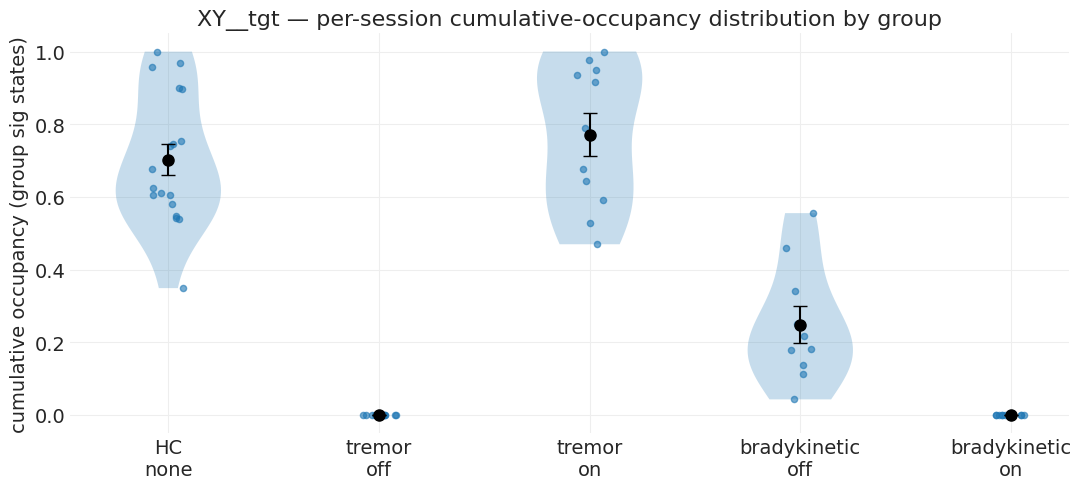

Per-group distribution (shapiro_p<0.05 => non-normal; NaN => n<3 or zero-variance spike):


,n,mean,std,median,min,max,shapiro_p
group,,,,,,,
HC_none,18,0.7024,0.1811,0.6509,0.3490,0.9997,0.2438
tremor_off,11,0.0000,0.0000,0.0000,0.0000,0.0000,NaN
tremor_on,11,0.7707,0.1957,0.7904,0.4697,1.0000,0.1611
bradykinetic_off,10,0.2478,0.1602,0.2000,0.0429,0.5553,0.4040
bradykinetic_on,10,0.0000,0.0000,0.0000,0.0000,0.0000,NaN


In [ ]:
from scipy.stats import shapiro

GORDER = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GORDER = [g for g in GORDER if ((cum_occ_df["subtype"] == g[0]) & (cum_occ_df["medication"] == g[1])).any()]
labels = [f"{s}\n{m}" for s, m in GORDER]
vals = [cum_occ_df[(cum_occ_df["subtype"] == s) & (cum_occ_df["medication"] == m)]["cum_occ"].values for s, m in GORDER]

fig, ax = plt.subplots(figsize=(11, 5))
rng = np.random.default_rng(0)
for i, v in enumerate(vals):
    if len(v) > 1 and np.ptp(v) > 0:
        p = ax.violinplot([v], positions=[i], showmeans=False, showextrema=False)
        for pc in p["bodies"]:
            pc.set_alpha(0.25)
            pc.set_facecolor("tab:blue")
    ax.scatter(rng.uniform(-0.08, 0.08, len(v)) + i, v, s=20, alpha=0.6, color="tab:blue", zorder=3)
    ax.errorbar(i, np.mean(v), yerr=(np.std(v, ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0), color="k", marker="o", ms=8, capsize=5, zorder=4)
ax.set_xticks(range(len(GORDER)))
ax.set_xticklabels(labels)
ax.set(ylabel="cumulative occupancy (group sig states)", ylim=(-0.05, 1.05), title=f"{SELECTED_MODEL} — per-session cumulative-occupancy distribution by group")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


def _shapiro_p(v):
    v = np.asarray(v)
    return np.nan if (len(v) < 3 or np.ptp(v) == 0) else float(shapiro(v).pvalue)


dist_tbl = pd.DataFrame([dict(group=f"{s}_{m}", n=len(v), mean=v.mean(), std=(v.std(ddof=1) if len(v) > 1 else 0.0), median=float(np.median(v)), min=v.min(), max=v.max(), shapiro_p=_shapiro_p(v)) for (s, m), v in zip(GORDER, vals)]).set_index(
    "group"
)
print("Per-group distribution (shapiro_p<0.05 => non-normal; NaN => n<3 or zero-variance spike):")
dist_tbl.round(4)

### Pairwise tests on cumulative occupancy

OFF and ON are the **same subjects**, so within-subject contrasts are **paired** (Wilcoxon on
per-subject OFF→ON differences); HC-vs-PD-OFF is between-subject (Mann-Whitney). BCa 95% CI +
bootstrap p as in §8.

**WARNING:** on this per-group-own-set `cum_occ`, the group with no significant state is
all-zeros (Tremor-OFF, Brady-ON), so within-subject rows have a zero-variance condition and their
p-values are **artifactual** (flagged `degenerate=True`). Interpret only with a fixed state set.

In [ ]:
from scipy.stats import mannwhitneyu

B_RESAMP, RNG = 10000, 0


def _ci_p(stat, *samples):
    try:
        res = bootstrap(samples, stat, method="BCa", n_resamples=B_RESAMP, random_state=RNG)
    except Exception:
        res = bootstrap(samples, stat, method="percentile", n_resamples=B_RESAMP, random_state=RNG)
    d = res.bootstrap_distribution
    return (float(res.confidence_interval.low), float(res.confidence_interval.high), float(np.clip(2 * min(np.mean(d <= 0), np.mean(d >= 0)), 0, 1)))


def within_cum(sub):
    pv = cum_occ_df[cum_occ_df["subtype"] == sub].pivot_table(index="subject_id", columns="medication", values="cum_occ").dropna(subset=["off", "on"])
    diffs = (pv["on"] - pv["off"]).to_numpy()
    degen = pv["off"].nunique() == 1 or pv["on"].nunique() == 1
    try:
        _, p = wilcoxon(pv["off"], pv["on"])
    except Exception:
        p = np.nan
    lo, hi, pb = _ci_p(np.mean, diffs)
    return dict(contrast=f"{sub} OFF vs ON", test="Wilcoxon(paired)", n=len(pv), baseline=pv["off"].mean(), comparison=pv["on"].mean(), delta=diffs.mean(), p_exact=p, ci_lo=lo, ci_hi=hi, p_boot=pb, degenerate=degen)


def between_cum(sub):
    a = cum_occ_df[cum_occ_df["subtype"] == "HC"]["cum_occ"].to_numpy()
    b = cum_occ_df[(cum_occ_df["subtype"] == sub) & (cum_occ_df["medication"] == "off")]["cum_occ"].to_numpy()
    degen = a.std() == 0 or b.std() == 0
    _, p = mannwhitneyu(a, b)

    def diff(x, y, axis=-1):
        return np.mean(y, axis=axis) - np.mean(x, axis=axis)

    lo, hi, pb = _ci_p(diff, a, b)
    return dict(contrast=f"HC vs {sub}-OFF", test="MWU", n=f"{len(a)}v{len(b)}", baseline=a.mean(), comparison=b.mean(), delta=b.mean() - a.mean(), p_exact=p, ci_lo=lo, ci_hi=hi, p_boot=pb, degenerate=degen)


cmp_cum = pd.DataFrame([between_cum("tremor"), between_cum("bradykinetic"), within_cum("tremor"), within_cum("bradykinetic")]).set_index("contrast")
print("Pairwise tests on cumulative occupancy of each group's significant color-effect states:")
cmp_cum[["test", "n", "baseline", "comparison", "delta", "p_exact", "ci_lo", "ci_hi", "p_boot", "degenerate"]].round(4)

Pairwise tests on cumulative occupancy of each group's significant color-effect states:


,test,n,baseline,comparison,delta,p_exact,ci_lo,ci_hi,p_boot,degenerate
contrast,,,,,,,,,,
HC vs tremor-OFF,MWU,18v11,0.7024,0.0000,-0.7024,0.0000,-0.7852,-0.6241,0.0,True
HC vs bradykinetic-OFF,MWU,18v10,0.7024,0.2478,-0.4546,0.0001,-0.5702,-0.3208,0.0,False
tremor OFF vs ON,Wilcoxon(paired),11,0.0000,0.7707,0.7707,0.0010,0.6564,0.8757,0.0,True
bradykinetic OFF vs ON,Wilcoxon(paired),10,0.2478,0.0000,-0.2478,0.0020,-0.3561,-0.1662,0.0,True
